# Imports

In [1]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from dataclasses import dataclass
from pathlib import Path
from datetime import datetime
from concurrent.futures import ProcessPoolExecutor
from functools import partial
from sklearn.cluster import KMeans

In [2]:
PLOT_COLORS = ("#1f77b4", "#ff7f0e", "#2ca02c", "#AA4A44", "#CBC3E3")
FONT_SIZES = {"small": 18, "medium": 24, "large": 28}

matplotlib.rcParams.update(
    {
        "figure.figsize": (12, 8),
        "figure.titlesize": FONT_SIZES["large"],
        "font.size": FONT_SIZES["medium"],
        "axes.labelsize": FONT_SIZES["medium"],
        "axes.titlesize": FONT_SIZES["medium"],
        "xtick.labelsize": FONT_SIZES["medium"],
        "ytick.labelsize": FONT_SIZES["medium"],
        "legend.fontsize": FONT_SIZES["medium"],
    }
)

# Data Loading & Processing

In [22]:
@dataclass(frozen=True)
class Config:
    root: Path
    rate_map: dict
    test_plan: dict
    phy_rates: dict
    kernels: tuple
    iterations: int

    @property
    def rates(self) -> tuple:
        return tuple(self.test_plan.keys())

    @property
    def delays(self) -> tuple:
        return tuple(dict.fromkeys(
            delay for cases in self.test_plan.values() for _, delay in cases
        ))

    @property
    def conditions(self) -> list[tuple]:
        return [
            (r, bw, delay, i)
            for r, cases in self.test_plan.items()
            for bw, delay in cases
            for i in range(1, self.iterations + 1)
        ]

    def get_rate_name(self, rate: int) -> str:
        return self.rate_map.get(rate, f"Rate{rate}")

    def base(self, rate, bw, delay, iteration):
        return f"rate{rate}_bw{bw}_delay{delay}_iter{iteration}"

    def dmesg_path(self, kernel, rate, bw, delay, iteration):
        return (
            self.root
            / kernel
            / "dmesg"
            / f"{self.base(rate, bw, delay, iteration)}.txt"
        )

    def raw_path(self, kernel, rate, bw, delay, iteration):
        return (
            self.root / kernel / "raw" /
            f"{self.base(rate, bw, delay, iteration)}.json"
        )

    def debug_log_path(self, kernel, rate, bw, delay):
        return (self.root / kernel / "logs" /
                f"rate{rate}_bw{bw}_delay{delay}.log")

    def log_path(self, kernel):
        return (self.root / kernel / "session.log")


config = Config(
    root=Path("../results/main_test/").resolve(),
    rate_map={
        67: "HT20-SGI-MCS3",
        71: "HT20-SGI-MCS7",
        195: "HT40-SGI-MCS3",
        199: "HT40-SGI-MCS7",
    },
    phy_rates={
        67: 28.9,  # HT20-SGI-MCS3,  1 stream,  28.9 Mbps nominal
        71: 72.2,  # HT20-SGI-MCS7,  1 stream,  72.2 Mbps nominal
        195: 60.0,  # HT40-SGI-MCS14, 1 streams, 60 Mbps nominal
        199: 150.0,  # HT40-SGI-MCS7,  1 stream, 150 Mbps nominal
    },
    test_plan={
        67: [("nolim", "nodelay"), ("nolim", "10"), ("nolim", "50"), ("nolim", "100"), ("12", "nodelay")],
        71: [("nolim", "nodelay"), ("nolim", "10"), ("nolim", "50"), ("nolim", "100"), ("30", "nodelay")],
        195: [("nolim", "nodelay"), ("nolim", "10"), ("nolim", "50"), ("nolim", "100"), ("26", "nodelay")],
        199: [("nolim", "nodelay"), ("nolim", "10"), ("nolim", "50"), ("nolim", "100"), ("70", "nodelay")],
    },
    kernels=("default", "tcpaad_20", "tcpaad_30", "tcpaad_50"),
    iterations=5,
)


print("Project root:", config.root, config.root.exists())
print(f"Conditions: {len(config.conditions)}")

Project root: /home/nyrik/temp/experiment/results/main_test True
Conditions: 100


In [23]:
perf_rows = []
for kernel in config.kernels:
    for rate, bw, delay, iteration in config.conditions:
        jf = config.raw_path(kernel, rate, bw, delay, iteration)
        if not jf.exists():
            continue
        with open(jf) as f:
            d = json.load(f)

        try:
            sender = d["end"]["streams"][0]["sender"]
        except (KeyError, IndexError) as e:
            raise RuntimeError(f"Malformed iperf3 JSON in {jf}: {e}")

        perf_rows.append(
            {
                "kernel": kernel,
                "rate": rate,
                "rate_name": config.get_rate_name(rate),
                "bw": bw,
                "delay": delay,
                "iteration": iteration,
                "bytes": sender["bytes"],
                "seconds": sender["seconds"],
                "bits_per_second": sender["bits_per_second"],
                "retransmits": sender.get("retransmits", 0),
                "reorder": sender.get("reorder", 0),
                "max_snd_cwnd": sender.get("max_snd_cwnd", 0),
                "max_snd_wnd": sender.get("max_snd_wnd", 0),
                "mean_rtt_us": sender.get("mean_rtt", 0),
                "min_rtt_us": sender.get("min_rtt", 0),
                "max_rtt_us": sender.get("max_rtt", 0),
            }
        )

df = pd.DataFrame(perf_rows)
df

,kernel,rate,rate_name,bw,delay,iteration,bytes,seconds,bits_per_second,retransmits,reorder,max_snd_cwnd,max_snd_wnd,mean_rtt_us,min_rtt_us,max_rtt_us
0,default,67,HT20-SGI-MCS3,nolim,nodelay,1,265945088,90.002038,2.363903e+07,36,0,152040,2317312,43126,26732,60298
1,default,67,HT20-SGI-MCS3,nolim,nodelay,2,265682944,90.001963,2.361575e+07,36,0,153488,1658880,44065,28485,57561
2,default,67,HT20-SGI-MCS3,nolim,nodelay,3,265945088,90.001708,2.363911e+07,39,0,144800,784896,42207,26363,61589
3,default,67,HT20-SGI-MCS3,nolim,nodelay,4,265551872,90.001635,2.360418e+07,37,0,169416,2409984,43418,26498,58911
4,default,67,HT20-SGI-MCS3,nolim,nodelay,5,265682944,90.001665,2.361582e+07,38,0,146248,1903616,41596,30601,55898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,tcpaad_50,199,HT40-SGI-MCS7,70,nodelay,1,517210112,90.001369,4.597353e+07,669,0,330144,13301248,20134,2179,112744
396,tcpaad_50,199,HT40-SGI-MCS7,70,nodelay,2,517865472,90.001512,4.603171e+07,514,0,222992,13301248,17878,10369,97415
397,tcpaad_50,199,HT40-SGI-MCS7,70,nodelay,3,518258688,90.001593,4.606662e+07,517,0,237472,6615552,16842,8906,53515
398,tcpaad_50,199,HT40-SGI-MCS7,70,nodelay,4,516161536,90.000585,4.588073e+07,619,0,292496,8786944,17773,2152,82739


# Throughput

In [24]:
throughput = df.pivot_table(
    index=["rate_name", "bw", "delay", "iteration"],
    columns="kernel",
    values="bits_per_second",
).round(2)

delta_pct = throughput.drop(columns="default").sub(throughput["default"], axis=0).div(throughput["default"], axis=0).mul(100).round(2)
delta_pct.columns = [f"{k} Δ%" for k in delta_pct.columns]
throughput = pd.concat([throughput, delta_pct], axis=1)

throughput_avg = throughput.groupby(level=["rate_name", "bw", "delay"]).mean().round(2)
throughput_std = throughput.groupby(level=["rate_name", "bw", "delay"]).std().round(2)

print("Throughput")
print("--- Per iteration ---")
print(throughput.to_string())
print("\n--- Avg per condition ---")
print(throughput_avg.to_string())
print("\n--- Std per condition ---")
print(throughput_std.to_string())


Throughput
--- Per iteration ---
                                            default     tcpaad_20     tcpaad_30     tcpaad_50  tcpaad_20 Δ%  tcpaad_30 Δ%  tcpaad_50 Δ%
rate_name     bw    delay   iteration                                                                                                  
HT20-SGI-MCS3 12    nodelay 1          1.148748e+07  1.152252e+07  1.154571e+07  1.153413e+07          0.30          0.51          0.41
                            2          1.148755e+07  1.152247e+07  1.156907e+07  1.153407e+07          0.30          0.71          0.41
                            3          1.149916e+07  1.155742e+07  1.153413e+07  1.154578e+07          0.51          0.30          0.41
                            4          1.151086e+07  1.152253e+07  1.152257e+07  1.154566e+07          0.10          0.10          0.30
                            5          1.149911e+07  1.153413e+07  1.153406e+07  1.154575e+07          0.30          0.30          0.41
              n

# phy utilization

In [25]:
# phy utilization

df["phy_utilization"] = df["bits_per_second"] / (df["rate"].map(config.phy_rates) * 1e6) * 100

phy_util = df.pivot_table(
    index=["rate_name", "bw", "delay", "iteration"],
    columns="kernel",
    values="phy_utilization",
).round(2)

phy_util_avg = phy_util.groupby(level=["rate_name", "bw", "delay"]).mean().round(2)
phy_util_std = phy_util.groupby(level=["rate_name", "bw", "delay"]).std().round(2)

print("Phy Utilization")
print("--- PHY utilization (%) per iteration ---")
print(phy_util.to_string())
print("\n--- PHY utilization (%) avg per condition ---")
print(phy_util_avg.to_string())
print("\n--- PHY utilization (%) std per condition ---")
print(phy_util_std.to_string())


Phy Utilization
--- PHY utilization (%) per iteration ---
kernel                                 default  tcpaad_20  tcpaad_30  tcpaad_50
rate_name     bw    delay   iteration                                          
HT20-SGI-MCS3 12    nodelay 1            39.75      39.87      39.95      39.91
                            2            39.75      39.87      40.03      39.91
                            3            39.79      39.99      39.91      39.95
                            4            39.83      39.87      39.87      39.95
                            5            39.79      39.91      39.91      39.95
              nolim 10      1            80.95      81.51      81.35      82.36
                            2            80.47      81.27      81.55      81.39
                            3            81.07      81.35      81.27      81.07
                            4            81.11      81.19      81.55      82.32
                            5            80.87      81.59     

# Retransmissions

In [26]:
retransmissions = df.pivot_table(
    index=["rate_name", "bw", "delay", "iteration"],
    columns="kernel",
    values="retransmits",
).astype(int)

delta = retransmissions.drop(columns="default").sub(retransmissions["default"], axis=0)
delta.columns = [f"{k} Δ" for k in delta.columns]
retransmissions = pd.concat([retransmissions, delta], axis=1)

retransmissions_avg = retransmissions.groupby(level=["rate_name", "bw", "delay"]).mean().round(1)
retransmissions_std = retransmissions.groupby(level=["rate_name", "bw", "delay"]).std().round(1)

print("retransmissions")
print("--- Per iteration ---")
print(retransmissions.to_string())
print("\n--- Avg per condition ---")
print(retransmissions_avg.to_string())
print("\n--- Std per condition ---")
print(retransmissions_std.to_string())


retransmissions
--- Per iteration ---
                                       default  tcpaad_20  tcpaad_30  tcpaad_50  tcpaad_20 Δ  tcpaad_30 Δ  tcpaad_50 Δ
rate_name     bw    delay   iteration                                                                                 
HT20-SGI-MCS3 12    nodelay 1                0          0          0          0            0            0            0
                            2                0          0          0          0            0            0            0
                            3                0          0          0          0            0            0            0
                            4                0          0          0          0            0            0            0
                            5                0          0          0          0            0            0            0
              nolim 10      1               27         28         31         28            1            4            1
          

# RTT

In [27]:
rtt_index = ["rate_name", "bw", "delay", "iteration"]
rtt_group = ["rate_name", "bw", "delay"]

print("RTT")
for stat in ["mean_rtt_us", "min_rtt_us", "max_rtt_us"]:
    rtt = df.pivot_table(index=rtt_index, columns="kernel", values=stat).round(0).astype(int)

    delta = rtt.drop(columns="default").sub(rtt["default"], axis=0)
    delta.columns = [f"{k} Δ" for k in delta.columns]
    rtt = pd.concat([rtt, delta], axis=1)

    rtt_avg = rtt.groupby(level=rtt_group).mean().round(0).astype(int)
    rtt_std = rtt.groupby(level=rtt_group).std().round(0).astype(int)

    print(f"\n--- {stat} per iteration ---")
    print(rtt.to_string())
    print(f"\n--- {stat} avg per condition ---")
    print(rtt_avg.to_string())
    print(f"\n--- {stat} std per condition ---")
    print(rtt_std.to_string())


RTT

--- mean_rtt_us per iteration ---
                                       default  tcpaad_20  tcpaad_30  tcpaad_50  tcpaad_20 Δ  tcpaad_30 Δ  tcpaad_50 Δ
rate_name     bw    delay   iteration                                                                                 
HT20-SGI-MCS3 12    nodelay 1            21117      47909      48503      54710        26792        27386        33593
                            2            14057      47645      53753      48919        33588        39696        34862
                            3            21171      53586      54418      53865        32415        33247        32694
                            4            21218      66086      47744      60989        44868        26526        39771
                            5            20268      46664      53837      48468        26396        33569        28200
              nolim 10      1            52779      54573      52016      56593         1794         -763         3814
         

## Reorder

In [28]:
reorder = df.pivot_table(
    index=["rate_name", "bw", "delay", "iteration"],
    columns="kernel",
    values="reorder",
).astype(int)

delta = reorder.drop(columns="default").sub(reorder["default"], axis=0)
delta.columns = [f"{k} Δ" for k in delta.columns]
reorder = pd.concat([reorder, delta], axis=1)

reorder_avg = reorder.groupby(level=["rate_name", "bw", "delay"]).mean().round(1)

print("Reorder")
print("--- Per iteration ---")
print(reorder.to_string())
print("\n--- Avg per condition ---")
print(reorder_avg.to_string())

Reorder
--- Per iteration ---
                                       default  tcpaad_20  tcpaad_30  tcpaad_50  tcpaad_20 Δ  tcpaad_30 Δ  tcpaad_50 Δ
rate_name     bw    delay   iteration                                                                                 
HT20-SGI-MCS3 12    nodelay 1                0          0          0          0            0            0            0
                            2                0          0          0          0            0            0            0
                            3                0          0          0          0            0            0            0
                            4                0          0          0          0            0            0            0
                            5                0          0          0          0            0            0            0
              nolim 10      1                0          0          0          0            0            0            0
                  

# Max Congestion Window

In [29]:
congestion_window = df.pivot_table(
    index=["rate_name", "bw", "delay", "iteration"],
    columns="kernel",
    values="max_snd_cwnd",
).astype(int)

delta = congestion_window.drop(columns="default").sub(congestion_window["default"], axis=0)
delta.columns = [f"{k} Δ" for k in delta.columns]
congestion_window = pd.concat([congestion_window, delta], axis=1)

congestion_window_avg = congestion_window.groupby(level=["rate_name", "bw", "delay"]).mean().round(0).astype(int)
congestion_window_std = congestion_window.groupby(level=["rate_name", "bw", "delay"]).std().round(0).astype(int)

print("Max congestion window")
print("--- Per iteration ---")
print(congestion_window.to_string())
print("\n--- Avg per condition ---")
print(congestion_window_avg.to_string())
print("\n--- Std per condition ---")
print(congestion_window_std.to_string())


Max congestion window
--- Per iteration ---
                                       default  tcpaad_20  tcpaad_30  tcpaad_50  tcpaad_20 Δ  tcpaad_30 Δ  tcpaad_50 Δ
rate_name     bw    delay   iteration                                                                                 
HT20-SGI-MCS3 12    nodelay 1            65160     147696     149144     149144        82536        83984        83984
                            2            46336     143352     194032     152040        97016       147696       105704
                            3            75296     194032     194032     144800       118736       118736        69504
                            4            75296     149144     141904     147696        73848        66608        72400
                            5            70952     134664     149144     149144        63712        78192        78192
              nolim 10      1           183896     185344     279464     312768         1448        95568       128872
    

# Max Send Window (bytes)

In [31]:
send_window = df.pivot_table(
    index=["rate_name", "bw", "delay", "iteration"],
    columns="kernel",
    values="max_snd_wnd",
).astype(int)

delta = send_window.drop(columns="default").sub(send_window["default"], axis=0)
delta.columns = [f"{k} Δ" for k in delta.columns]
send_window = pd.concat([send_window, delta], axis=1)

send_window_avg = send_window.groupby(level=["rate_name", "bw", "delay"]).mean().round(0).astype(int)
send_window_std = send_window.groupby(level=["rate_name", "bw", "delay"]).std().round(0).astype(int)

print("Max Send Window")
print("--- Per iteration ---")
print(send_window.to_string())
print("\n--- Avg per condition ---")
print(send_window_avg.to_string())
print("\n--- Std per condition ---")
print(send_window_std.to_string())


Max Send Window
--- Per iteration ---
                                        default  tcpaad_20  tcpaad_30  tcpaad_50  tcpaad_20 Δ  tcpaad_30 Δ  tcpaad_50 Δ
rate_name     bw    delay   iteration                                                                                  
HT20-SGI-MCS3 12    nodelay 1            118272      97792      95232     108032       -20480       -23040       -10240
                            2             82944     104960     107520      96768        22016        24576        13824
                            3            106496     101376     110080     102400        -5120         3584        -4096
                            4            121856     181248      95232     121856        59392       -26624            0
                            5            111104      93696     101376      95232       -17408        -9728       -15872
              nolim 10      1           2188288    1051648    3542528    3187712     -1136640      1354240       999424
  

## ACK Count

In [32]:
ack_rows = []
for kernel in config.kernels:
    for rate, cases in config.test_plan.items():
        for bw, delay in cases:
            path = config.debug_log_path(kernel, rate, bw, delay)
            if not path.exists():
                continue
            cur_iter = None
            for line in path.read_text().splitlines():
                m = re.search(r"^--- Iteration (\d+)", line)
                if m:
                    cur_iter = int(m.group(1))
                    continue
                m = re.search(r"ACK count\s*:\s*(\d+)", line)
                if m and cur_iter is not None:
                    ack_rows.append({
                        "kernel": kernel,
                        "rate": rate,
                        "rate_name": config.get_rate_name(rate),
                        "bw": bw,
                        "delay": delay,
                        "iteration": cur_iter,
                        "ack_count": int(m.group(1)),
                    })

df_acks = pd.DataFrame(ack_rows)
if df_acks.empty:
    print("No ACK count data found in logs")
else:
    ack_count = df_acks.pivot_table(
        index=["rate_name", "bw", "delay", "iteration"],
        columns="kernel",
        values="ack_count",
    ).astype(int)

    delta = ack_count.drop(columns="default").sub(ack_count["default"], axis=0)
    delta_pct = delta.div(ack_count["default"], axis=0).mul(100).round(2)
    delta.columns = [f"{k} Δ" for k in delta.columns]
    delta_pct.columns = [f"{k} Δ%" for k in delta_pct.columns]
    ack_count = pd.concat([ack_count, delta, delta_pct], axis=1)

    ack_count_avg = ack_count.groupby(level=["rate_name", "bw", "delay"]).mean().round(1)
    ack_count_std = ack_count.groupby(level=["rate_name", "bw", "delay"]).std().round(1)

    print("ACK Count")
    print("--- Per iteration ---")
    print(ack_count.to_string())
    print("\n--- Avg per condition ---")
    print(ack_count_avg.to_string())
    print("\n--- Std per condition ---")
    print(ack_count_std.to_string())


ACK Count
--- Per iteration ---
                                       default  tcpaad_20  tcpaad_30  tcpaad_50  tcpaad_20 Δ  tcpaad_30 Δ  tcpaad_50 Δ  tcpaad_20 Δ%  tcpaad_30 Δ%  tcpaad_50 Δ%
rate_name     bw    delay   iteration                                                                                                                           
HT20-SGI-MCS3 12    nodelay 1            24043       2588       2579       2185       -21455       -21464       -21858        -89.24        -89.27        -90.91
                            2            35687       3102       2425       2561       -32585       -33262       -33126        -91.31        -93.20        -92.82
                            3            22721       2319       2270       2429       -20402       -20451       -20292        -89.79        -90.01        -89.31
                            4            22610       1909       2624       2060       -20701       -19986       -20550        -91.56        -88.39        -90.89
  

# aggregation level

In [33]:
agg_rows = []
for kernel in config.kernels:
    for rate, cases in config.test_plan.items():
        for bw, delay in cases:
            path = config.debug_log_path(kernel, rate, bw, delay)
            if not path.exists():
                continue
            cur_iter = None
            agg_count = 0
            for line in path.read_text().splitlines():
                m = re.search(r"^--- Iteration (\d+)", line)
                if m:
                    cur_iter = int(m.group(1))
                    agg_count = 0
                    continue
                m = re.search(r"Average # of aggregated frames per A-MPDU:\s*([\d.]+)", line)
                if m and cur_iter is not None:
                    agg_count += 1
                    if agg_count == 2:  # post-run value
                        agg_rows.append({
                            "kernel": kernel,
                            "rate": rate,
                            "rate_name": config.get_rate_name(rate),
                            "bw": bw,
                            "delay": delay,
                            "iteration": cur_iter,
                            "ampdu_avg": float(m.group(1)),
                        })

df_agg = pd.DataFrame(agg_rows)
if df_agg.empty:
    print("No aggregation data found in logs")
else:
    aggregation = df_agg.pivot_table(
        index=["rate_name", "bw", "delay", "iteration"],
        columns="kernel",
        values="ampdu_avg",
    ).round(1)

    aggregation_avg = aggregation.groupby(level=["rate_name", "bw", "delay"]).mean().round(1)
    aggregation_std = aggregation.groupby(level=["rate_name", "bw", "delay"]).std().round(1)

    print("--- A-MPDU aggregation level per iteration ---")
    print(aggregation.to_string())
    print("\n--- A-MPDU aggregation level avg per condition ---")
    print(aggregation_avg.to_string())
    print("\n--- A-MPDU aggregation level std per condition ---")
    print(aggregation_std.to_string())


--- A-MPDU aggregation level per iteration ---
kernel                                 default  tcpaad_20  tcpaad_30  tcpaad_50
rate_name     bw    delay   iteration                                          
HT20-SGI-MCS3 12    nodelay 1              2.4        2.3        2.3        2.3
                            2              1.6        2.3        2.6        2.4
                            3              2.6        2.6        2.6        2.3
                            4              2.6        2.3        2.3        2.3
                            5              2.6        2.3        2.3        2.3
              nolim 10      1              8.2        8.8        8.1        8.4
                            2              8.4        7.7        8.8        8.7
                            3              8.6        8.3        8.0        8.9
                            4              8.6        8.0        8.5        8.0
                            5              8.4        8.8        8.6     

# Plots

In [34]:
KERNEL_LABELS = {"default": "Default", "tcpaad_20": "α=2.0", "tcpaad_30": "α=3.0", "tcpaad_50": "α=5.0"}
CONDITION_ORDER = ["Baseline", "10ms", "50ms", "100ms", "BW cap"]
RATE_ORDER = ["HT20-SGI-MCS3", "HT20-SGI-MCS7", "HT40-SGI-MCS3", "HT40-SGI-MCS7"]
RATE_KEY = {v: k for k, v in config.rate_map.items()}

df["condition"] = np.where(
    df["bw"] != "nolim", "BW cap",
    np.where(df["delay"] == "nodelay", "Baseline", df["delay"] + "ms")
)

plot_dir = Path("plots")
plot_dir.mkdir(exist_ok=True)

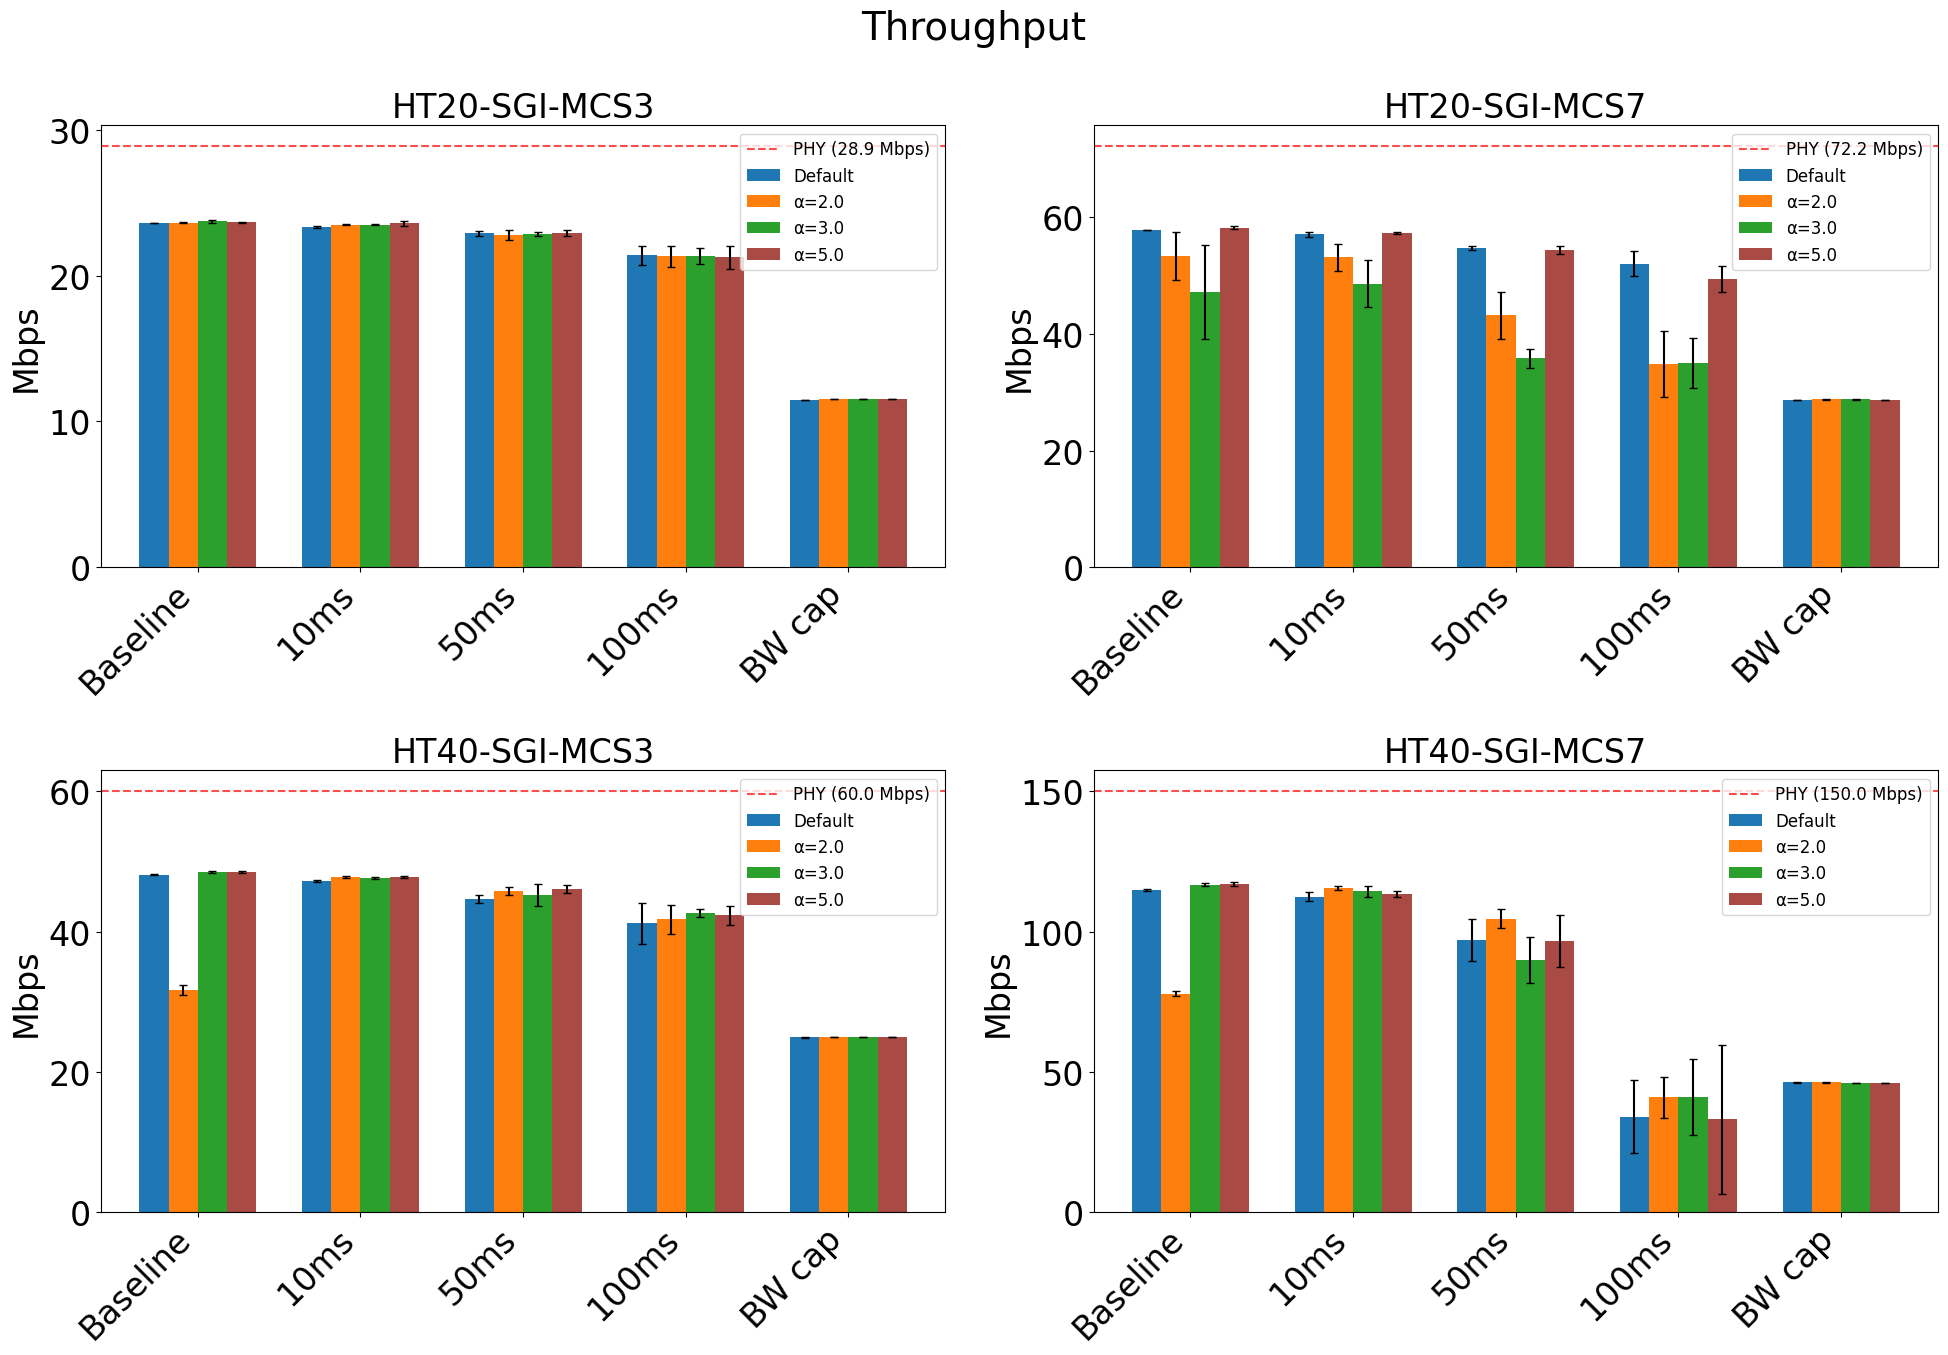

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle("Throughput")

for ax, rate_name in zip(axes.flat, RATE_ORDER):
    rate_df = df[df["rate_name"] == rate_name]
    stats = rate_df.groupby(["condition", "kernel"])["bits_per_second"].agg(["mean", "std"]).reset_index()

    x = np.arange(len(CONDITION_ORDER))
    width = 0.18

    for i, (kernel, label) in enumerate(KERNEL_LABELS.items()):
        ks = stats[stats["kernel"] == kernel].set_index("condition")
        means = [ks.loc[c, "mean"] / 1e6 if c in ks.index else 0 for c in CONDITION_ORDER]
        stds = [ks.loc[c, "std"] / 1e6 if c in ks.index else 0 for c in CONDITION_ORDER]
        ax.bar(x + i * width, means, width, yerr=stds, label=label, color=PLOT_COLORS[i], capsize=3)

    phy = config.phy_rates[RATE_KEY[rate_name]]
    ax.axhline(y=phy, color="red", linestyle="--", alpha=0.7, label=f"PHY ({phy} Mbps)")

    ax.set_title(rate_name)
    ax.set_ylabel("Mbps")
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right")
    ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig(plot_dir / "throughput.png", dpi=150, bbox_inches="tight")
plt.show()

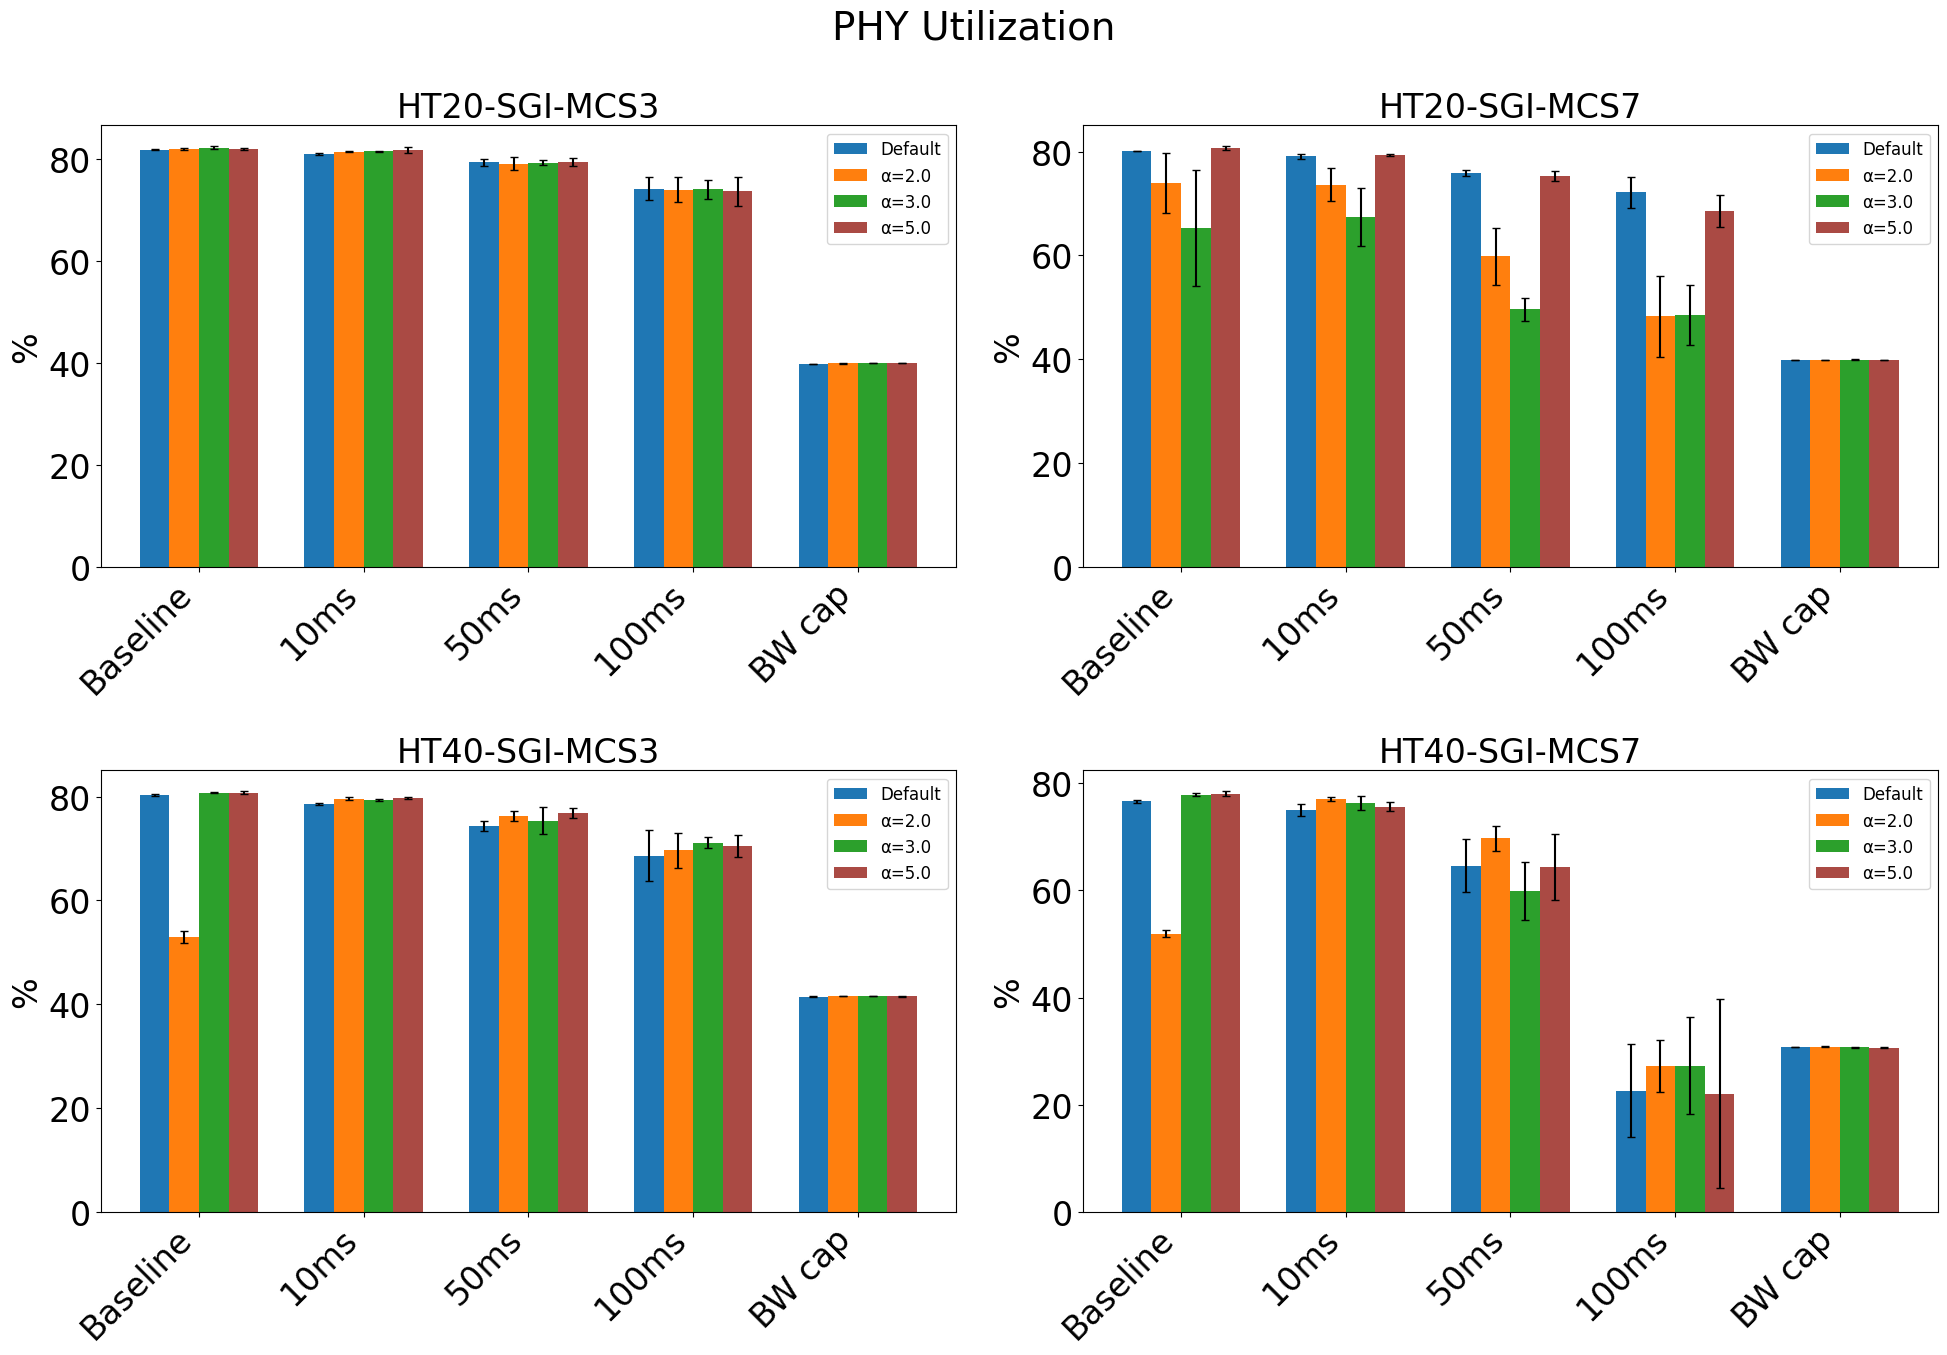

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle("PHY Utilization")

for ax, rate_name in zip(axes.flat, RATE_ORDER):
    rate_df = df[df["rate_name"] == rate_name]
    stats = rate_df.groupby(["condition", "kernel"])["phy_utilization"].agg(["mean", "std"]).reset_index()

    x = np.arange(len(CONDITION_ORDER))
    width = 0.18

    for i, (kernel, label) in enumerate(KERNEL_LABELS.items()):
        ks = stats[stats["kernel"] == kernel].set_index("condition")
        means = [ks.loc[c, "mean"] if c in ks.index else 0 for c in CONDITION_ORDER]
        stds = [ks.loc[c, "std"] if c in ks.index else 0 for c in CONDITION_ORDER]
        ax.bar(x + i * width, means, width, yerr=stds, label=label, color=PLOT_COLORS[i], capsize=3)

    ax.set_title(rate_name)
    ax.set_ylabel("%")
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right")
    ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig(plot_dir / "phy_utilization.png", dpi=150, bbox_inches="tight")
plt.show()

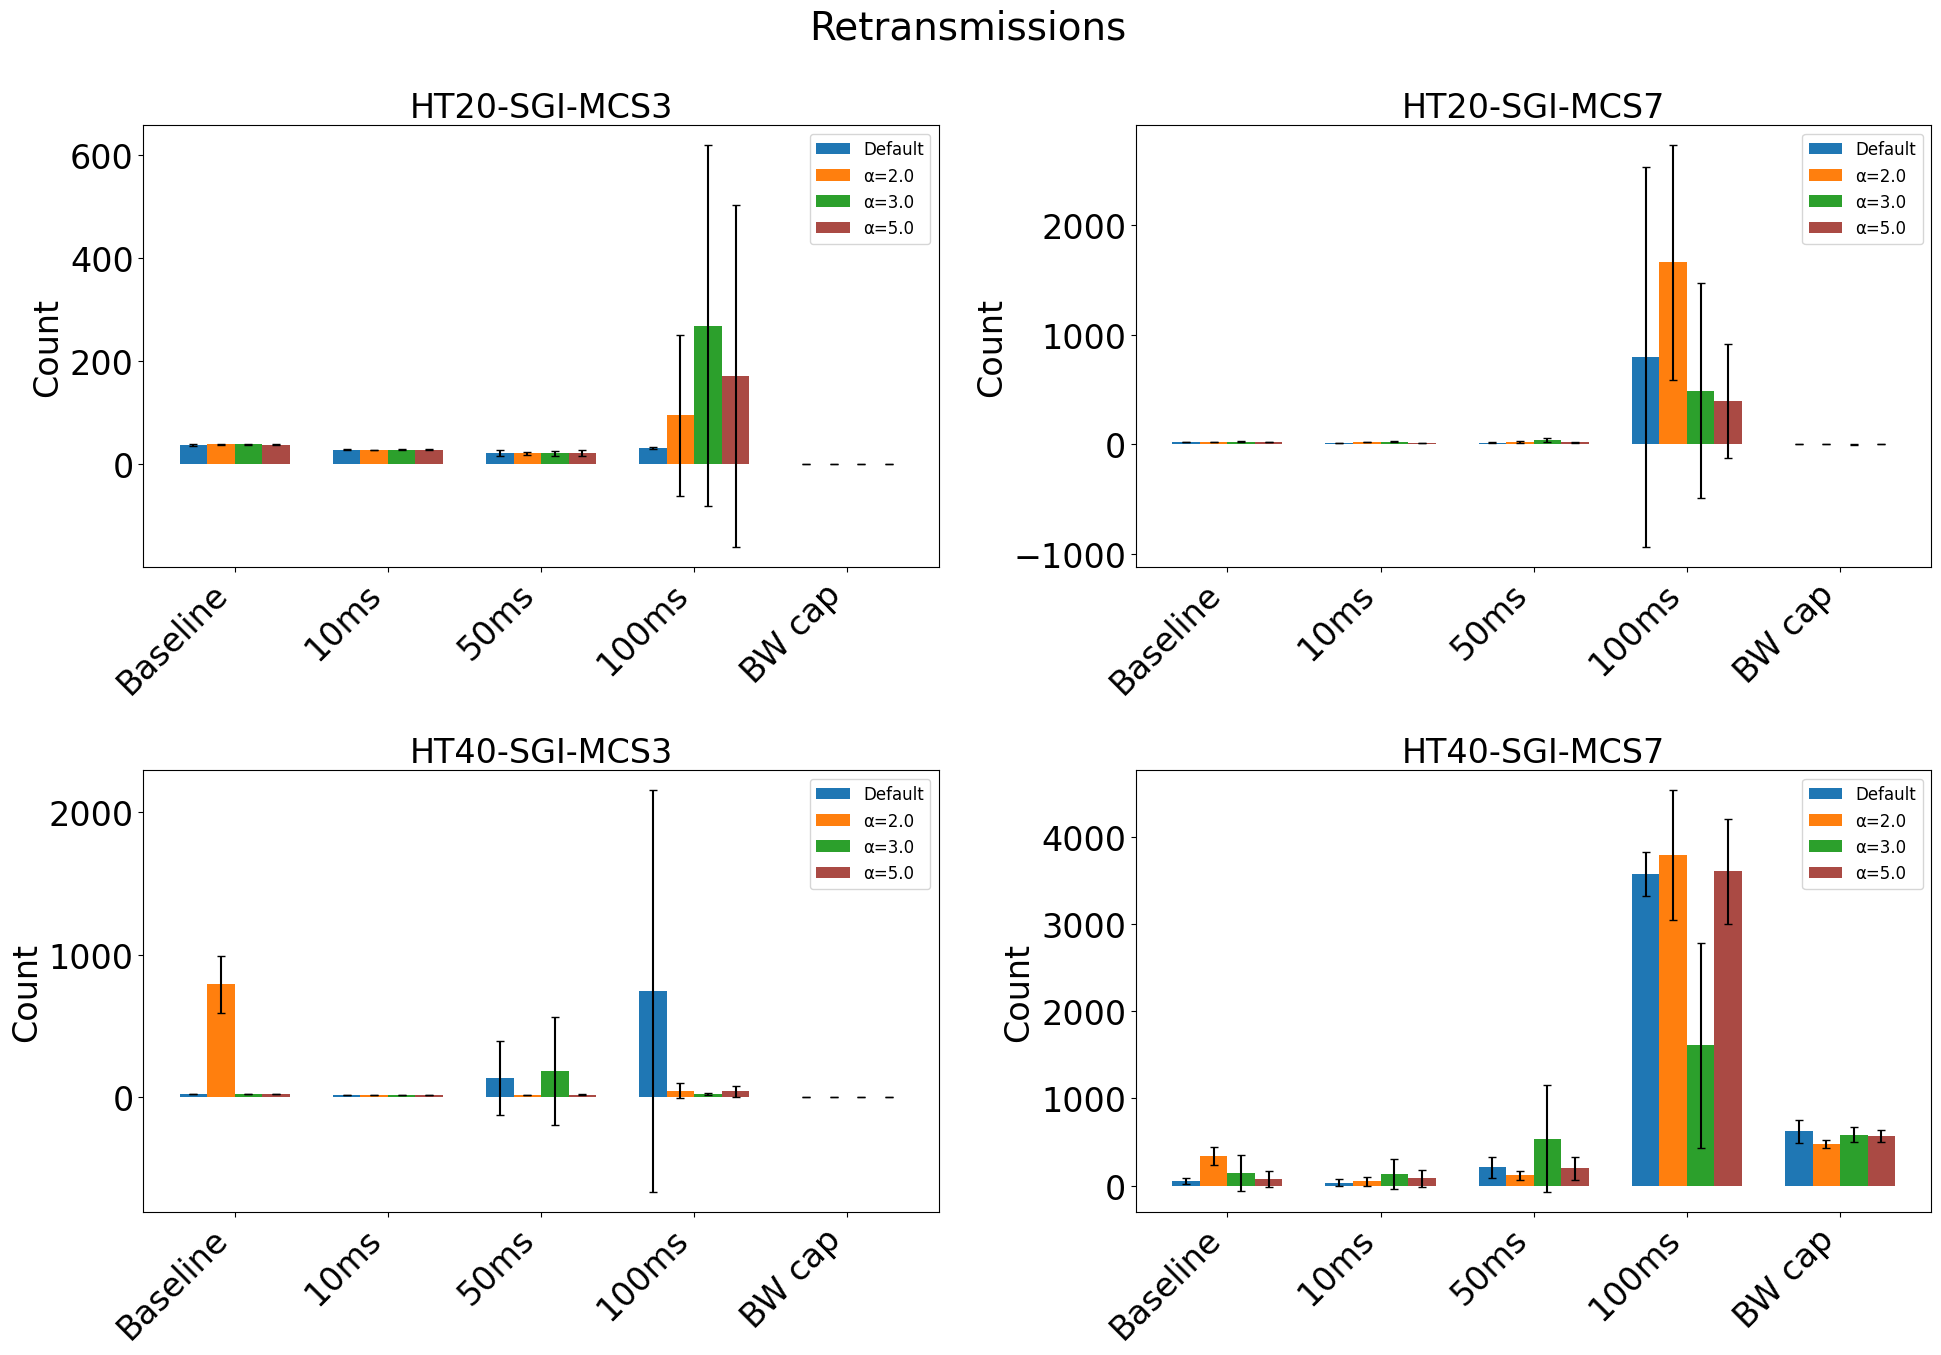

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle("Retransmissions")

for ax, rate_name in zip(axes.flat, RATE_ORDER):
    rate_df = df[df["rate_name"] == rate_name]
    stats = rate_df.groupby(["condition", "kernel"])["retransmits"].agg(["mean", "std"]).reset_index()

    x = np.arange(len(CONDITION_ORDER))
    width = 0.18

    for i, (kernel, label) in enumerate(KERNEL_LABELS.items()):
        ks = stats[stats["kernel"] == kernel].set_index("condition")
        means = [ks.loc[c, "mean"] if c in ks.index else 0 for c in CONDITION_ORDER]
        stds = [ks.loc[c, "std"] if c in ks.index else 0 for c in CONDITION_ORDER]
        ax.bar(x + i * width, means, width, yerr=stds, label=label, color=PLOT_COLORS[i], capsize=3)

    ax.set_title(rate_name)
    ax.set_ylabel("Count")
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right")
    ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig(plot_dir / "retransmissions.png", dpi=150, bbox_inches="tight")
plt.show()

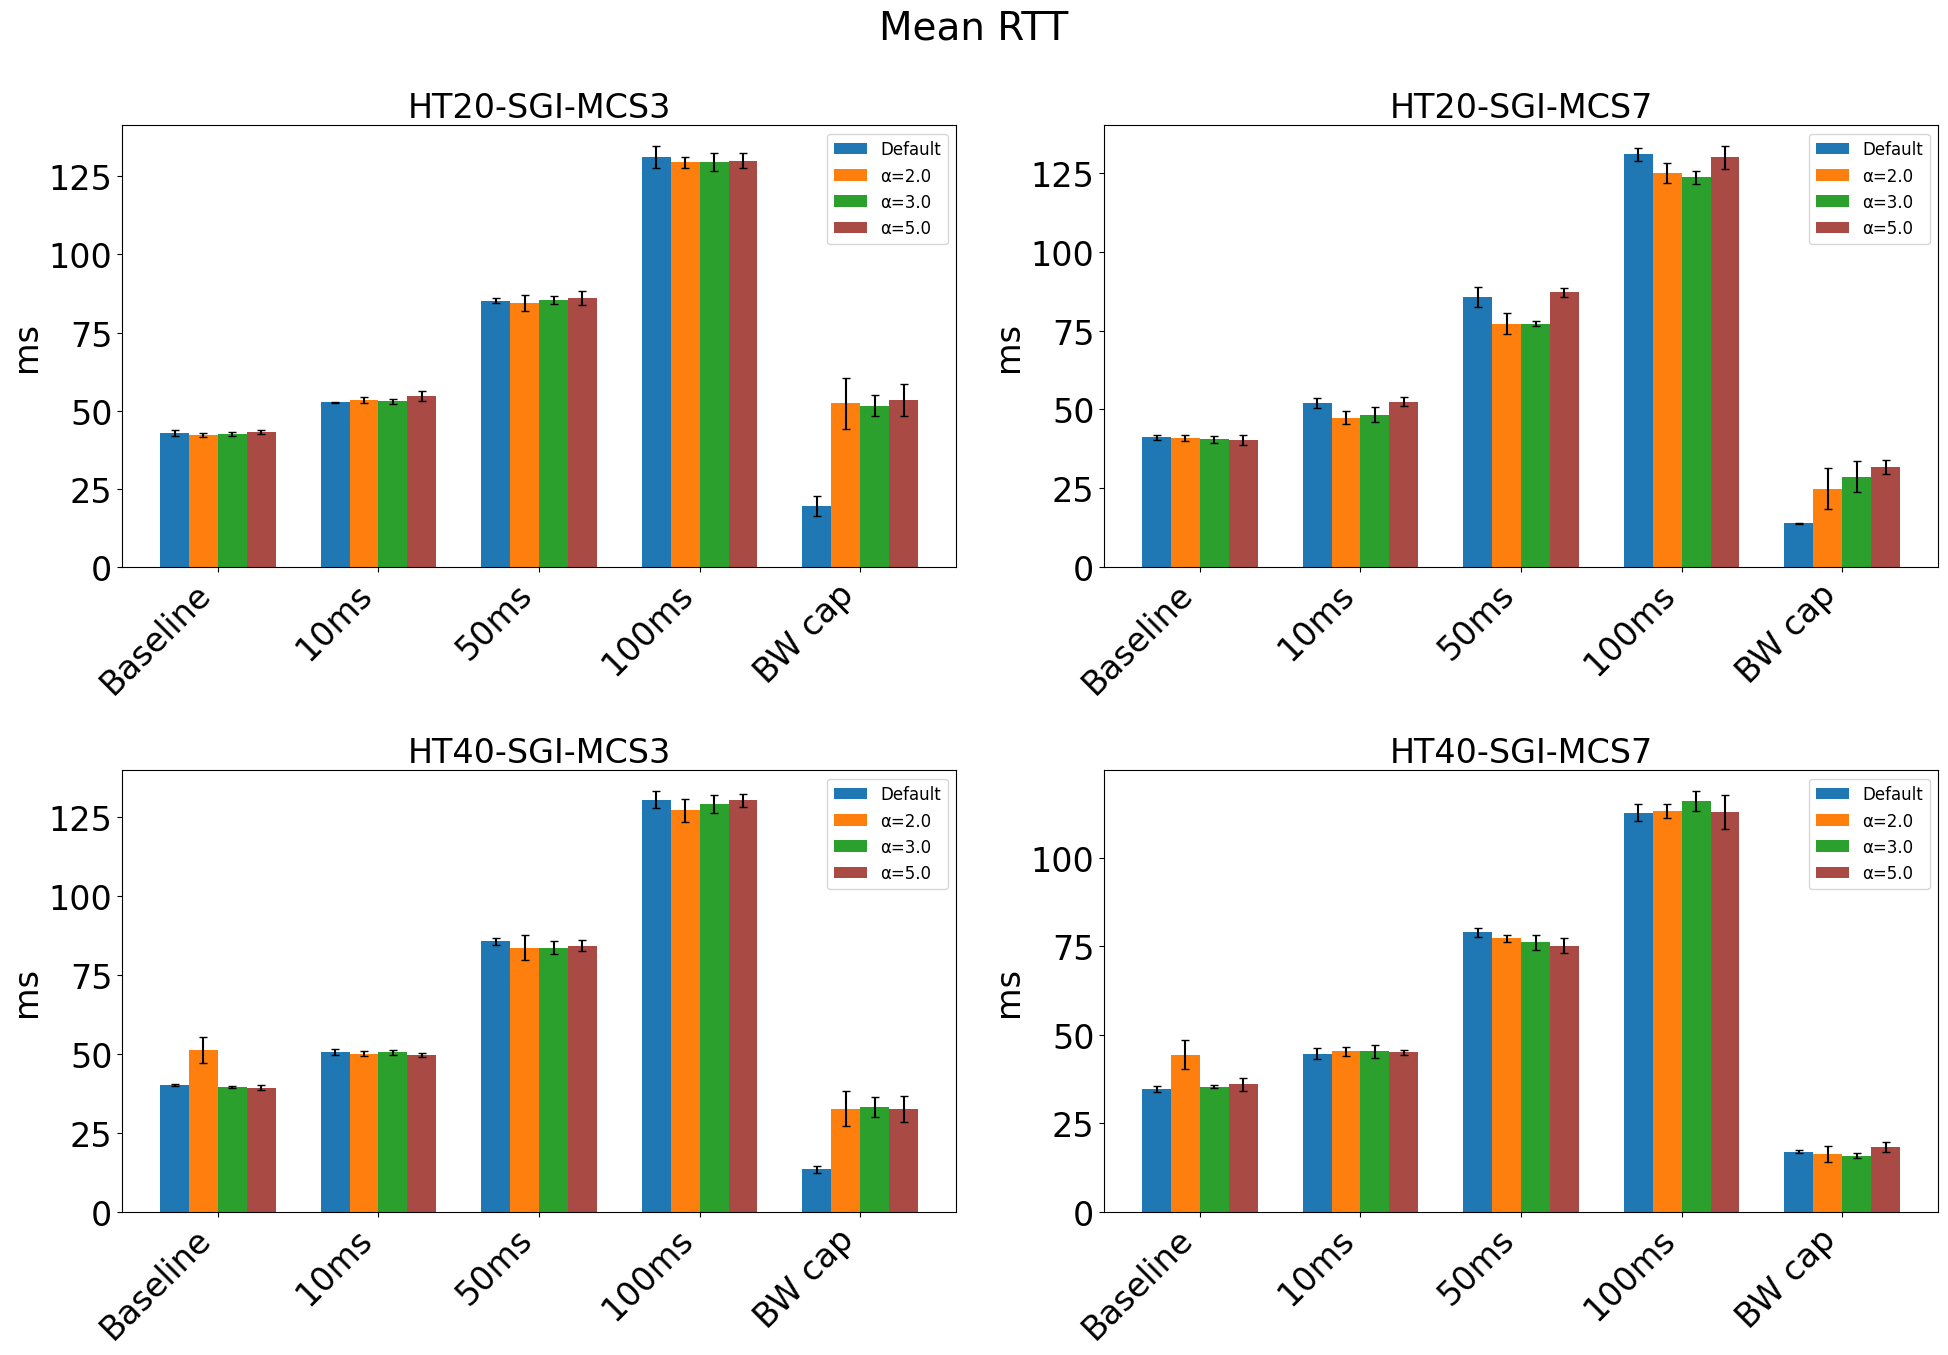

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle("Mean RTT")

for ax, rate_name in zip(axes.flat, RATE_ORDER):
    rate_df = df[df["rate_name"] == rate_name]
    stats = rate_df.groupby(["condition", "kernel"])["mean_rtt_us"].agg(["mean", "std"]).reset_index()

    x = np.arange(len(CONDITION_ORDER))
    width = 0.18

    for i, (kernel, label) in enumerate(KERNEL_LABELS.items()):
        ks = stats[stats["kernel"] == kernel].set_index("condition")
        means = [ks.loc[c, "mean"] / 1000 if c in ks.index else 0 for c in CONDITION_ORDER]
        stds = [ks.loc[c, "std"] / 1000 if c in ks.index else 0 for c in CONDITION_ORDER]
        ax.bar(x + i * width, means, width, yerr=stds, label=label, color=PLOT_COLORS[i], capsize=3)

    ax.set_title(rate_name)
    ax.set_ylabel("ms")
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right")
    ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig(plot_dir / "mean_rtt.png", dpi=150, bbox_inches="tight")
plt.show()

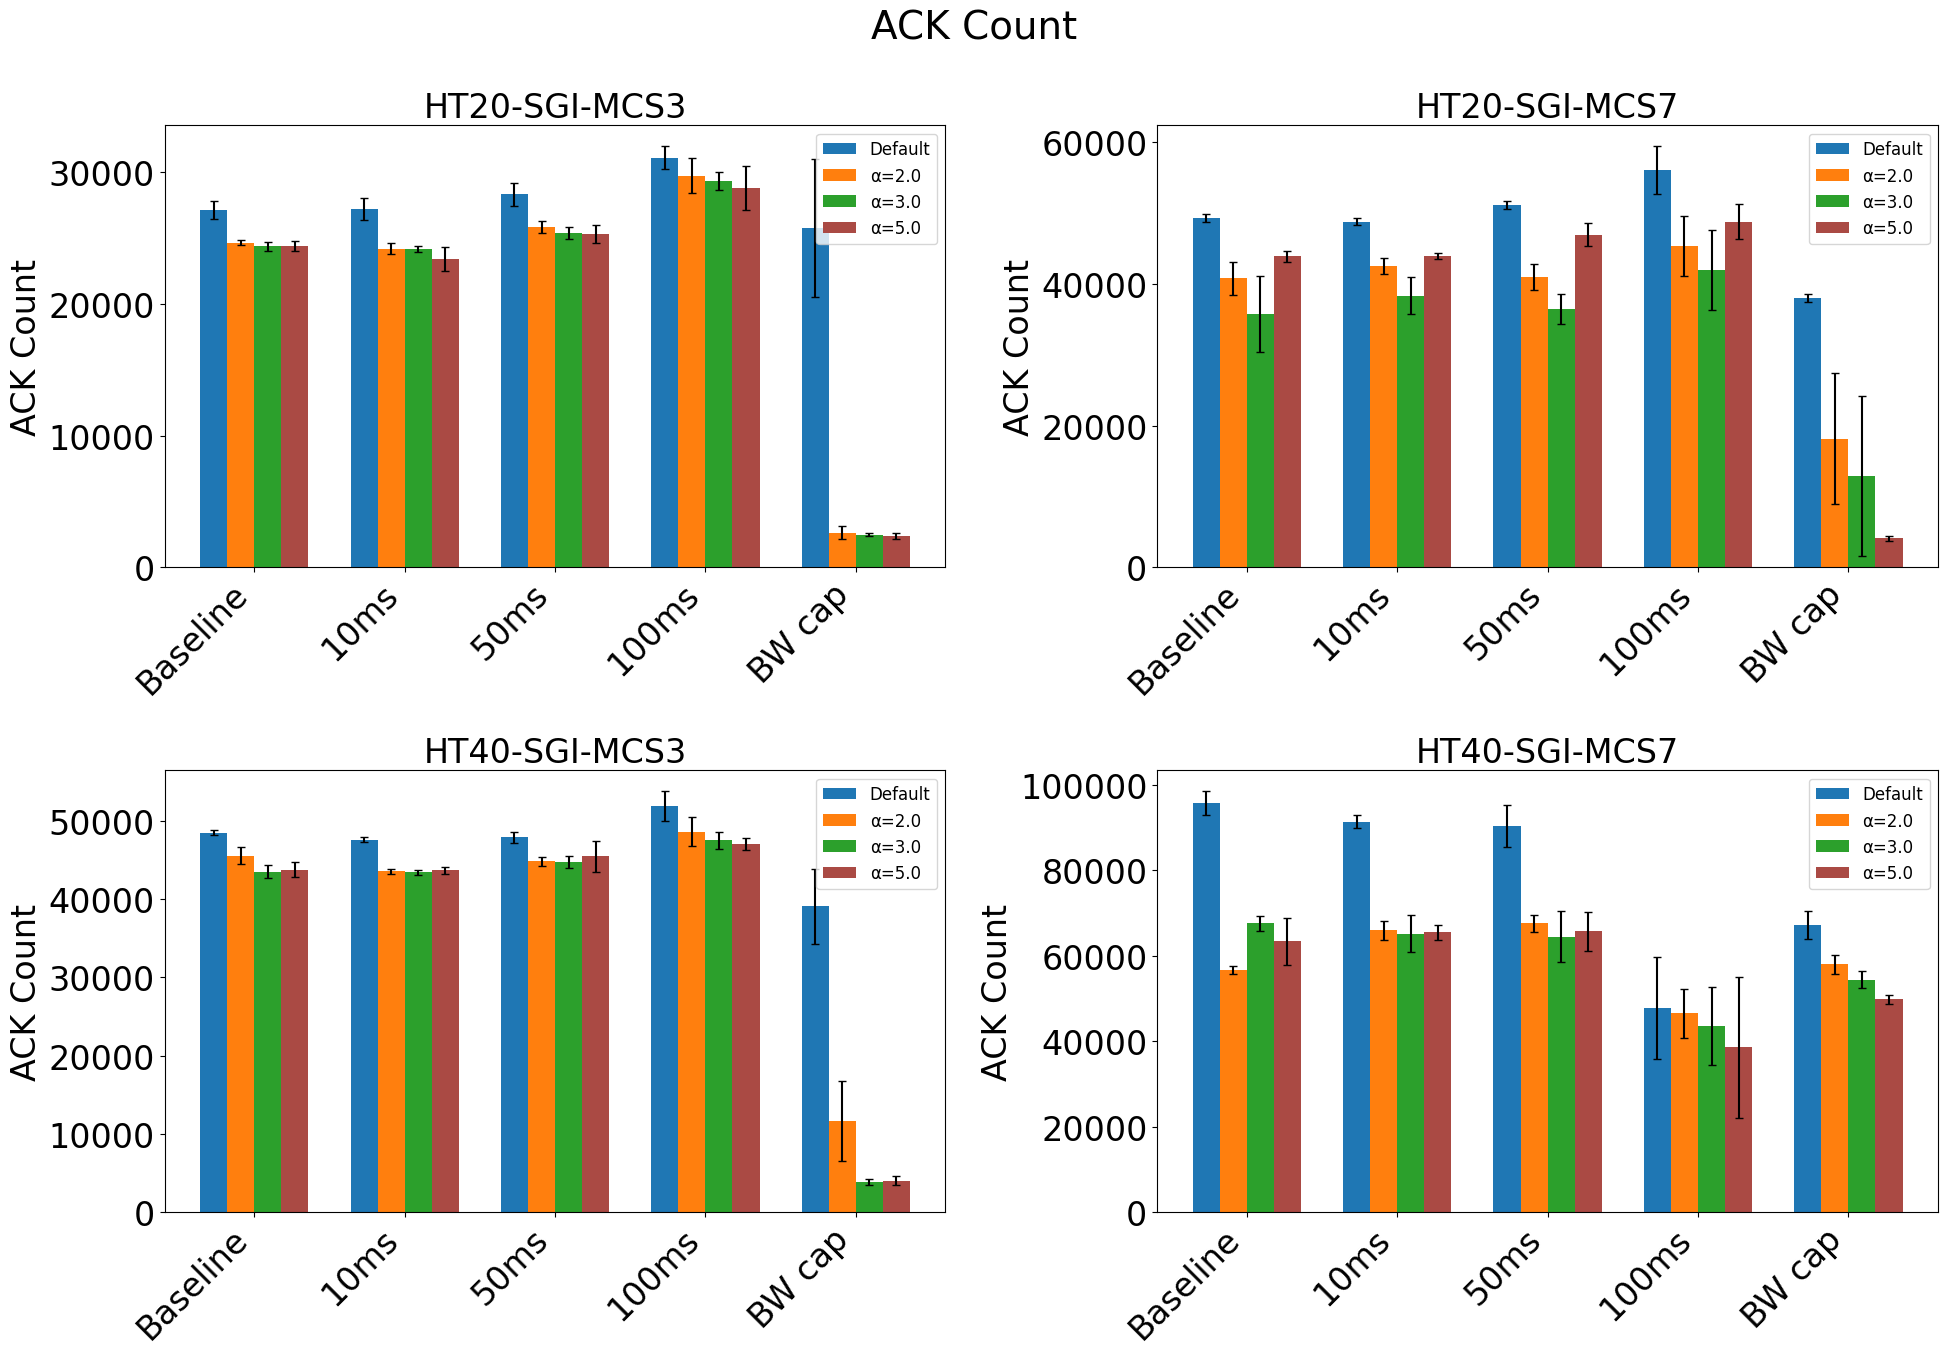

In [39]:
if not df_acks.empty:
    df_acks["condition"] = np.where(
        df_acks["bw"] != "nolim", "BW cap",
        np.where(df_acks["delay"] == "nodelay", "Baseline", df_acks["delay"] + "ms")
    )

    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle("ACK Count")

    for ax, rate_name in zip(axes.flat, RATE_ORDER):
        rate_df = df_acks[df_acks["rate_name"] == rate_name]
        stats = rate_df.groupby(["condition", "kernel"])["ack_count"].agg(["mean", "std"]).reset_index()

        x = np.arange(len(CONDITION_ORDER))
        width = 0.18

        for i, (kernel, label) in enumerate(KERNEL_LABELS.items()):
            ks = stats[stats["kernel"] == kernel].set_index("condition")
            means = [ks.loc[c, "mean"] if c in ks.index else 0 for c in CONDITION_ORDER]
            stds = [ks.loc[c, "std"] if c in ks.index else 0 for c in CONDITION_ORDER]
            ax.bar(x + i * width, means, width, yerr=stds, label=label, color=PLOT_COLORS[i], capsize=3)

        ax.set_title(rate_name)
        ax.set_ylabel("ACK Count")
        ax.set_xticks(x + width * 1.5)
        ax.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right")
        ax.legend(fontsize=12)

    plt.tight_layout()
    plt.savefig(plot_dir / "ack_count.png", dpi=150, bbox_inches="tight")
    plt.show()

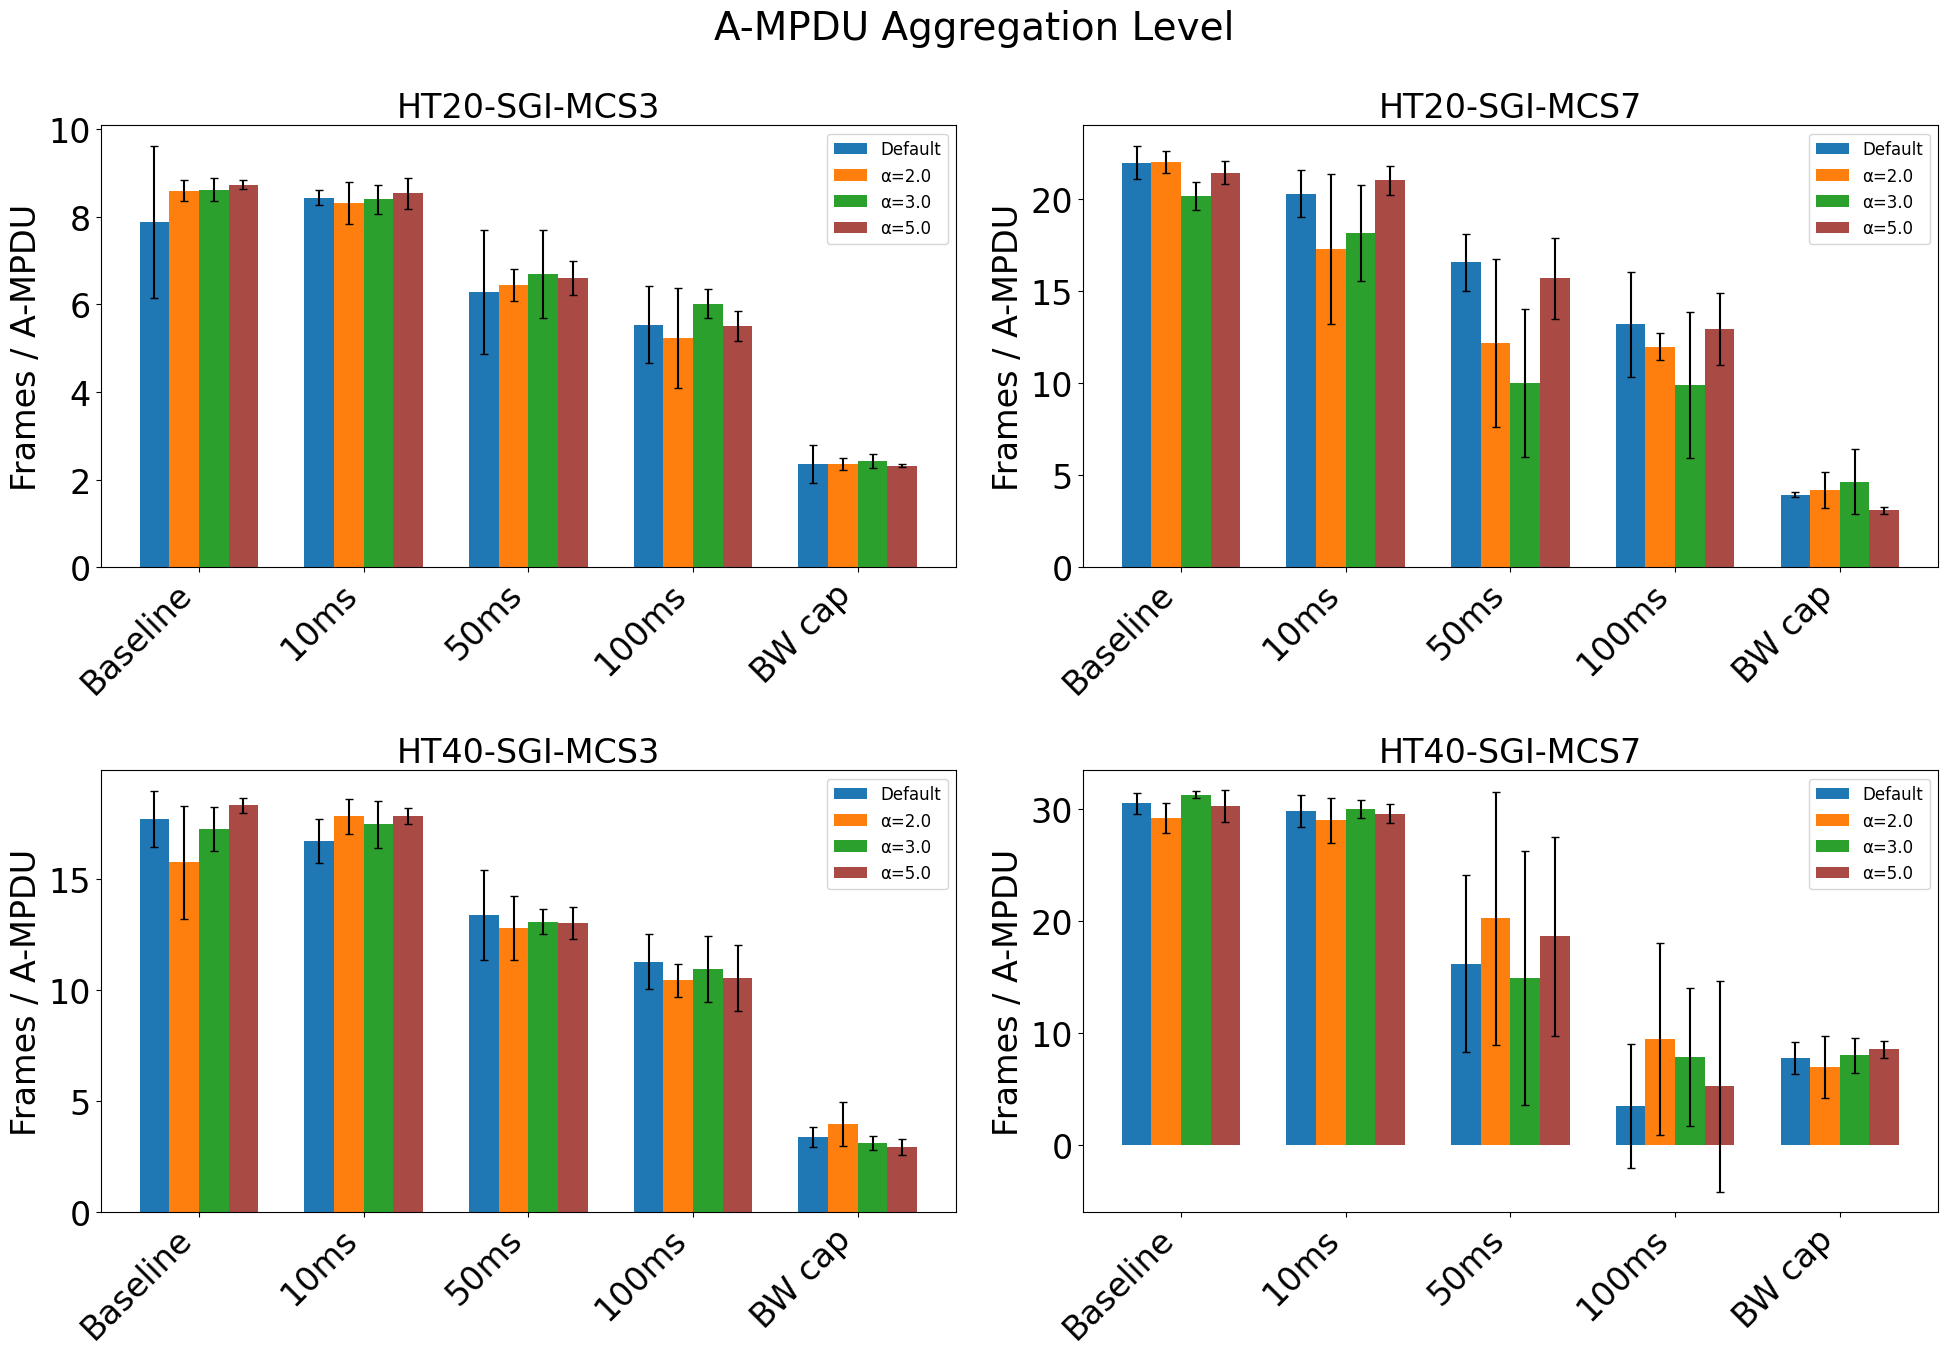

In [40]:
if not df_agg.empty:
    df_agg["condition"] = np.where(
        df_agg["bw"] != "nolim", "BW cap",
        np.where(df_agg["delay"] == "nodelay", "Baseline", df_agg["delay"] + "ms")
    )

    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle("A-MPDU Aggregation Level")

    for ax, rate_name in zip(axes.flat, RATE_ORDER):
        rate_df = df_agg[df_agg["rate_name"] == rate_name]
        stats = rate_df.groupby(["condition", "kernel"])["ampdu_avg"].agg(["mean", "std"]).reset_index()

        x = np.arange(len(CONDITION_ORDER))
        width = 0.18

        for i, (kernel, label) in enumerate(KERNEL_LABELS.items()):
            ks = stats[stats["kernel"] == kernel].set_index("condition")
            means = [ks.loc[c, "mean"] if c in ks.index else 0 for c in CONDITION_ORDER]
            stds = [ks.loc[c, "std"] if c in ks.index else 0 for c in CONDITION_ORDER]
            ax.bar(x + i * width, means, width, yerr=stds, label=label, color=PLOT_COLORS[i], capsize=3)

        ax.set_title(rate_name)
        ax.set_ylabel("Frames / A-MPDU")
        ax.set_xticks(x + width * 1.5)
        ax.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right")
        ax.legend(fontsize=12)

    plt.tight_layout()
    plt.savefig(plot_dir / "aggregation.png", dpi=150, bbox_inches="tight")
    plt.show()